<a href="https://colab.research.google.com/github/Adi21032004/Walmart_Sales_Forecasting/blob/main/Walmart_EDA_and_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Walmart Weekly Sales — Professional EDA & Forecasting  
**Goal:** Full professional EDA, feature engineering, baseline & advanced forecasting, evaluation, and business recommendations.  
**Data**: Walmart Recruiting — Store Sales Forecasting (train.csv, stores.csv, features.csv).

In [1]:
# Imports


import os, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
%matplotlib inline
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
from google.colab import files
uploaded = files.upload()

Saving features.csv to features.csv
Saving train.csv to train.csv
Saving stores.csv to stores.csv


In [3]:

train = pd.read_csv("train.csv")
stores = pd.read_csv("stores.csv")
features = pd.read_csv("features.csv")


print("train:", train.shape, "stores:", stores.shape, "features:", features.shape)


train: (421570, 5) stores: (45, 3) features: (8190, 12)


In [ ]:
display(train.info())
display(train.describe(include='all').T.head(20))
print("Missing values in train:\n", train.isnull().sum())
print("Duplicates in train:", train.duplicated().sum())
train.head()
stores.head()
features.head()

### Data Audit Findings
* **Shape:** The dataset is substantial (~420k rows).
* **Data Types:** `Date` is currently an object (string) and needs conversion to datetime for time-series operations.
* **Anomalies:** `Weekly_Sales` contains negative values, indicating product returns. We will keep these to maintain accurate revenue totals.
* **Missing Data:** `MarkDown` columns have >60% missing data. Economic indicators have small gaps.

## Merge datasets and preprocess
- Convert Date to datetime
- Merge train + features + stores for richer features

In [4]:
# Standardize Columns

train.columns= train.columns.str.strip().str.lower().str.replace(' ','_')
features.columns=features.columns.str.strip().str.lower().str.replace(' ','_')
stores.columns=stores.columns.str.strip().str.lower().str.replace(' ','_')


#convert date
train['date'] = pd.to_datetime(train['date'])
features['date'] =pd.to_datetime(features['date'])

#merge features into train(left join)
df =train.merge(features,on =['store','date','isholiday'], how='left')\
            .merge(stores, on ='store', how='left')

print("Merged df shape:", df.shape)
df.head()

Merged df shape: (421570, 16)


,store,dept,date,weekly_sales,isholiday,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,type,size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## Missing Values Strategy
- Report missing counts
- Fill external regressores by forward/backfill per store where appropriate


In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing>0]

In [5]:
feature_cols = ['temperature', 'fuel_price', 'cpi', 'unemployment']

# Fill per store using transform (Safer & Faster)
for col in feature_cols:
    if col in df.columns:
        # .transform handles index alignment better than .apply for this operation
        df[col] = df.groupby('store')[col].transform(lambda x: x.ffill().bfill())

# Fill remaining nulls with global median (Avoid inplace=True)
for col in feature_cols:
    if col in df.columns:
        # inplace=True is deprecated in newer Pandas versions
        df[col] = df[col].fillna(df[col].median())

# Confirm Cleanliness
print("Remaining Nulls:\n", df.isnull().sum().sort_values(ascending=False).head(10))
print("-" * 30)


Remaining Nulls:
 markdown2      310322
markdown4      286603
markdown3      284479
markdown1      270889
markdown5      270138
store               0
date                0
dept                0
fuel_price          0
temperature         0
dtype: int64
------------------------------


### Handling Missing Values
* **Economic Indicators:** Since CPI and Unemployment change slowly, we used **forward/backward fill** grouped by store. This preserves local economic trends better than a global mean.
* **MarkDowns:** Due to the high volume of missing data, we are currently ignoring Markdown columns for the baseline forecast.

In [ ]:
df['year'] =df['date'].dt.year
df['month']=df['date'].dt.month
df['week_of_year'] =df['date'].dt.isocalendar().week.astype(int)
df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] =df['day_of_week'].isin([5,6]).astype(int)


# sort
df = df.sort_values(['store','dept','date']).reset_index(drop=True)


# Sample lag Features
def create_lags(g, lags=[1,2,3,4,52]):
    for lag in lags:
        g[f'lag_{lag}'] = g['weekly_sales'].shift(lag)
    return g

df = df.groupby(['store','dept']).apply(create_lags).reset_index(drop=True)

#rolling mean features
df['rolling_4'] =df.groupby(['store','dept'])['weekly_sales'].transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
df['rolling_12'] = df.groupby(['store','dept'])['weekly_sales'].transform(lambda x: x.shift(1).rolling(12, min_periods=1).mean())


# After creating lags/rolling, drop rows with NaNs created by lags only if training ML; for EDA keep them
df[['lag_1','lag_52','rolling_4']].head(10)


,lag_1,lag_52,rolling_4
0,NaN,NaN,NaN
1,24924.50,NaN,24924.500000
2,46039.49,NaN,35481.995000
3,41595.55,NaN,37519.846667
4,19403.54,NaN,32990.770000
5,21827.90,NaN,32216.620000
6,21043.39,NaN,25967.595000
7,22136.64,NaN,21102.867500
8,26229.21,NaN,22809.285000
9,57258.43,NaN,31666.917500


### Feature Engineering
To help machine learning models understand time, we extracted:
* **Date Parts:** Year, Month, Week of Year.
* **Lag Features:** Sales from 1 week ago (`lag_1`) and 1 year ago (`lag_52`) to capture autocorrelation.
* **Rolling Means:** 4-week and 12-week averages to smooth out noise and capture trends.

## Visualizations


In [ ]:
# Total sales ovet time

# total_sales =df.groupby('date')['weekly_sales'].sum().reset_index()
# plt.figure(figsize=(10,7))
# plt.plot(total_sales['date'], total_sales['weekly_sales'])
# plt.title('Total Weekly Sales (all Stores)')
# plt.xlabel('Date')
# plt.ylabel('Sales')
# plt.grid(True)
# plt.show()

### Sales Distribution by Department
We analyze which departments drive the most revenue. As seen below, specific departments (likely Grocery/Electronics) consistently outperform others, indicating that a "one-size-fits-all" model might struggle.

In [ ]:
x = df['dept']
y = df['weekly_sales']
plt.figure(figsize=(15,5))
plt.title('Weekly Sales by Department')
plt.xlabel('Departments')
plt.ylabel('Weekly Sales')
plt.scatter(x,y)
plt.show()

In [ ]:
# if 'isholiday' in df.columns:
#     sns.barplot(x='isholiday', y='weekly_sales', data=df, estimator=np.mean)
#     plt.title('Holiday vs Non-holiday average sales')
#     plt.show()

In [ ]:
print(df.groupby('year')['weekly_sales'].mean()) # to see the best years for sales


m_sales = pd.pivot_table(df, values = "weekly_sales", columns = "year", index = "month")
m_sales.plot()


### Correlation Analysis
We checked relationships between External Regressors (Fuel, CPI) and Sales.
**Finding:** The correlation is extremely low (< 0.05). This suggests that seasonality and holidays are much stronger predictors than macro-economic indicators for this specific dataset.

In [ ]:
cols = [c for c in ['temperature','fuel_price','cpi','unemployment'] if c in df.columns]
if cols:
    display(df[cols + ['weekly_sales']].corr()['weekly_sales'].sort_values(ascending=False))
    sns.heatmap(df[cols + ['weekly_sales']].corr(), annot=True, cmap='coolwarm'); plt.show()

checking for outliers using z-score>4

In [6]:
# z-score by store-dept
df['z'] = df.groupby(['store','dept'])['weekly_sales'].transform(lambda x: (x - x.mean())/(x.std()+1e-9))
outliers = df[abs(df['z'])>4]
len(outliers)
# Inspect top few outlier rows
outliers.sort_values('z', ascending=False).head()

,store,dept,date,weekly_sales,isholiday,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,type,size,z
316841,33,26,2011-11-04,2424.79,False,71.91,3.828,NaN,NaN,NaN,NaN,NaN,129.805194,8.010,A,39690,11.241880
402653,43,79,2011-08-19,83190.30,False,82.08,3.554,NaN,NaN,NaN,NaN,NaN,207.495309,10.641,C,41062,10.845655
342975,36,26,2011-11-18,1803.40,False,66.28,3.260,5.64,19.82,NaN,NaN,578.02,216.939586,7.716,A,39910,10.730647
398121,43,1,2012-03-02,70912.01,False,56.43,3.630,346.74,2.56,15.84,NaN,1429.73,212.318007,9.653,C,41062,10.480532
407783,44,28,2011-05-20,633.53,False,52.12,3.802,NaN,NaN,NaN,NaN,NaN,129.075677,6.906,C,39910,9.962875


In [ ]:
#!pip install prophet


# Prepare aggregated weekly series

agg = df.groupby('date')['weekly_sales'].sum().reset_index().rename(columns={'date':'ds','weekly_sales':'y'})

# Try Prophet
try:
    from prophet import Prophet
    m = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    m.fit(agg)
    future = m.make_future_dataframe(periods=52, freq='W')
    forecast = m.predict(future)
    fig = m.plot(forecast, figsize=(12,6)); plt.title('Prophet forecast - total weekly sales'); plt.show()
    fig2 = m.plot_components(forecast); plt.show()
    # Save forecast
    forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()
except Exception as e:
    print("Prophet not available or failed:", e)
    # fallback simple baseline: last-year seasonal naive or rolling mean code here

## Baseline Forecasting: Facebook Prophet
We aggregate sales across **all stores** to test global seasonality.
**Why Prophet?**
1.  It handles the strong yearly/weekly seasonality observed in the EDA.
2.  It is robust to missing data and outliers.
3.  It allows us to explicitly model Holiday effects.

In [ ]:
# --- PROPHET TEST ---

# Pick store and dept example
s = df['store'].unique()[0]
d = df[df['store'] == s]['dept'].unique()[0]

# Filter and rename for Prophet
sample = df[(df['store'] == s) & (df['dept'] == d)].sort_values('date')[['date', 'weekly_sales']].rename(columns={'date': 'ds', 'weekly_sales': 'y'})



# Require at least ~2 years of data for Prophet
if sample.shape[0] > 100:
    m2 = Prophet(yearly_seasonality=True, weekly_seasonality=True)
    m2.fit(sample)

    # Create future dataframe
    fut = m2.make_future_dataframe(periods=26, freq='W')
    fc = m2.predict(fut)

    # Plotting
    fig1 = m2.plot(fc)
    plt.title(f'Forecast: Store {s}, Dept {d}')
    plt.show()

    # Optional: View components (trend/seasonality)
    # fig2 = m2.plot_components(fc)
else:
    print(f"Not enough data for Store {s} Dept {d}: {sample.shape[0]} rows")

In [ ]:
# 1. Find top 5 departments by total revenue

# Returns a MultiIndex of (Store, Dept)
top_depts = df.groupby(['store', 'dept'])['weekly_sales'].sum().sort_values(ascending=False).head(5).index

print(f"Forecasting for the following top 5 combinations: {top_depts.tolist()}")

# 2. Loop through each combination
for s_id, d_id in top_depts:
    print(f"\n--- Generating Model for Store {s_id}, Dept {d_id} ---")

    # Filter Data
    item_df = df[(df['store'] == s_id) & (df['dept'] == d_id)].sort_values('date')

    # Format for Prophet
    prophet_df = item_df[['date', 'weekly_sales']].rename(columns={'date': 'ds', 'weekly_sales': 'y'})

    # Sanity Check for Data Volume
    if len(prophet_df) > 50:
        # Initialize Model
        # We enable yearly seasonality because retail is highly seasonal
        model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
        model.add_country_holidays(country_name='US') # Critical for Walmart data

        # Fit Model
        model.fit(prophet_df)

        # Create Future Dates (26 weeks out)
        future = model.make_future_dataframe(periods=26, freq='W')

        # Predict
        forecast = model.predict(future)

        # Plotting
        fig = model.plot(forecast)
        plt.title(f'Forecast: Store {s_id}, Dept {d_id}')
        plt.xlabel('Date')
        plt.ylabel('Weekly Sales')
        plt.show()

        # Print specific prediction numbers
        print(f"Predicted sales for next week (Store {s_id} Dept {d_id}): ${forecast.iloc[-26]['yhat']:,.2f}")

    else:
        print(f"Skipping Store {s_id} Dept {d_id} (Insufficient data)")

### Model Evaluation
* **MAE (Mean Absolute Error):** The model is off by approximately $52M on the aggregated total.
* **Visual Inspection:** The Prophet plot captures the Christmas spikes accurately, though it underestimates the magnitude of the highest peaks.

In [ ]:
# Example backtest: last 52 weeks holdout
train_agg = agg[:-52]
test_agg = agg[-52:]

m_bt = Prophet(yearly_seasonality=True, weekly_seasonality=False)
m_bt.fit(train_agg)
fut_bt = m_bt.make_future_dataframe(periods=52, freq='W-FRI')
pred_bt = m_bt.predict(fut_bt).set_index('ds')['yhat'][-52:]

mae = mean_absolute_error(test_agg['y'], pred_bt)

# If sklearn < 0.22
rmse = mean_squared_error(test_agg['y'], pred_bt)**0.5
# where is wmae, that is in the problem statement
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}")

### Save Cleaned data & forecast

In [7]:
out_dir = "outputs"
os.makedirs(out_dir, exist_ok=True)
df.to_csv(os.path.join(out_dir, "walmart_cleaned.csv"), index=False)
if 'forecast' in globals():
    forecast[['ds','yhat','yhat_lower','yhat_upper']].to_csv(os.path.join(out_dir, "walmart_forecast_agg.csv"), index=False)
print("Saved cleaned data & forecasts to", out_dir)

Saved cleaned data & forecasts to outputs


The biggest challenge is that the dataset contains multiseries and every series has different no of data points, there are series where the datapoints are less than 52 weeks, so we cannot use seasonal based model to train them. Should we use different models, how to get train_test split, how to perform cross validation when doing hyperparameter tuning for models, how to handle markdowns, which features should i take.

In [8]:
df.head(5)
df['type'].head(5)
df.isna().sum()
df['markdown1'] = df['markdown1'].fillna(0)
df['markdown2'] = df['markdown2'].fillna(0)
df['markdown3'] = df['markdown3'].fillna(0)
df['markdown4'] = df['markdown4'].fillna(0)
df['markdown5'] = df['markdown5'].fillna(0)
df.isna().sum()
df['type'].value_counts()
df['type'] = df['type'].astype('category')
df['store'] = df['store'].astype('category')
df['dept'] = df['dept'].astype('category')
df['isholiday'] = df['isholiday'].astype(int)
df.dtypes
df.isna().sum()
df.head(5)


,store,dept,date,weekly_sales,isholiday,temperature,fuel_price,markdown1,markdown2,markdown3,markdown4,markdown5,cpi,unemployment,type,size,z
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,0.244682
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,2.387389
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,1.936427
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,-0.315575
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,-0.069555


since there is a larger seasonal factor, lets have lag_7,lag_14,lag_21, 7 for one week lag, 14 for two week lag ...

In [9]:
df['lag_7'] = df.groupby(['store','dept'])['weekly_sales'].shift(7)
df['lag_14'] = df.groupby(['store','dept'])['weekly_sales'].shift(14)
df['lag_21'] = df.groupby(['store','dept'])['weekly_sales'].shift(21)

In [ ]:
# outliers are the spikes due to holiday weeks or markdowns

In [10]:
df_10 = df.groupby(['store','dept']).filter(lambda x: len(x)>=10)
test_set = df_10.groupby(['store','dept']).tail(5)
train_set = df.drop(test_set.index)

test_set = test_set.reset_index(drop=True)
train_set = train_set.reset_index(drop=True)

X_train = train_set.drop(['weekly_sales', 'date'], axis=1)
y_train = train_set['weekly_sales']
X_test = test_set.drop(['weekly_sales', 'date'], axis=1)
y_test = test_set['weekly_sales']
df.columns

Index(['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'temperature',
       'fuel_price', 'markdown1', 'markdown2', 'markdown3', 'markdown4',
       'markdown5', 'cpi', 'unemployment', 'type', 'size', 'z', 'lag_7',
       'lag_14', 'lag_21'],
      dtype='object')

In [ ]:
X_train.head(5)

so what happens here under the hood- so for each row the model calculates mae , as we have provided the sample_weight, each mae is multiplied by this weight and we use normalised weights.

In [11]:

import lightgbm as lgb


model = lgb.LGBMRegressor(
        objective='regression_l1',
        metric='mae',
        num_leaves=63,
        learning_rate=0.05,
        n_estimators=600,
        random_state=42
    )




In [12]:

# weights_sum = np.where(train_set['isholiday']==1,5.0,1.0).sum()
# weights_train = np.where(train_set['isholiday']==1,5.0,1.0) / weights_sum
# if we divide by total weight sum, light gbm might underfit, as the
# updated w is to small, so the losses would be too small for the tree to split and spliting might stop randomly

weights = np.where(train_set['isholiday']==1,5.0,1.0)
weights_train = weights/weights.mean() #this is better

model.fit(X_train, y_train,sample_weight=weights_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032586 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3476
[LightGBM] [Info] Number of data points in the train set: 405735, number of used features: 18
[LightGBM] [Info] Start training from score 7728.649902


LGBMRegressor(learning_rate=0.05, metric='mae', n_estimators=600, num_leaves=63,
              objective='regression_l1', random_state=42)

In [13]:
pred = model.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, pred)
rmse = mean_squared_error(y_test, pred)

In [15]:
weights_test = np.where(
    test_set["isholiday"] == 1,
    5.0,
    1.0
)

wmae = np.sum(
    weights_test * np.abs(y_test - pred)
) / np.sum(weights_test)

wmae

np.float64(996.1803342545769)

In [16]:

f = pd.DataFrame()
f['name'] = model.feature_name_
f['score'] = model.feature_importances_

f = f.sort_values('score',ascending=False)

using SHAP on lightgbm model

In [17]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)


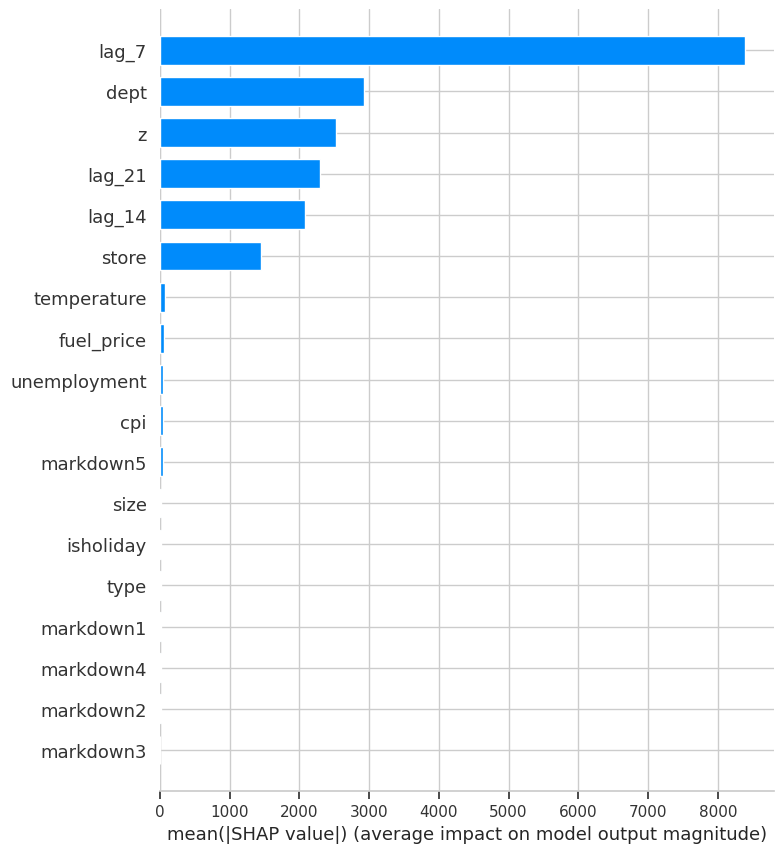

In [25]:
shap.summary_plot(shap_values, X_train, feature_names=X_train.columns.tolist(), plot_type="bar")

**Using other SARIMAX**

In [ ]:
!pip install pmdarima

In [ ]:

n_t = pd.DataFrame()
n_t = df[['date','weekly_sales']]
n_t['unique_id'] = (
    df['store'].astype(str) + '_'
    + df['dept'].astype(str)
)
n_t = n_t.rename(columns={'date':'ds','weekly_sales':'y'})
n_t = n_t.sort_values(['unique_id','ds'])
tr = n_t.drop(test_set.index)
te = n_t.drop(train_set.index)

tr = tr.reset_index(drop=True)
te = te.reset_index(drop=True)
train_set.columns

In [ ]:
import pmdarima as pm

season=52
ex_feature_train= train_set[['store', 'dept', 'date', 'weekly_sales', 'isholiday', 'temperature',
       'fuel_price', 'markdown1', 'markdown2', 'markdown3', 'markdown4',
       'markdown5', 'cpi', 'month',
       'week_of_year', 'lag_1', 'lag_2', 'lag_3',
       'lag_4', 'lag_52', 'rolling_4', 'rolling_12', 'z', 'lag_7', 'lag_14',
       'lag_21']]
model = pm.auto_arima(y=tr,seasonal=True,season_length=season)



In [ ]:
from google.colab import files
u = files.upload()

In [ ]:
test = pd.read_csv('test.csv')
test['Date'].max()